# Figure 2

Two blocks with the same four-panel shape, separated by a rule.

- **A** -- **D** the RSV-A truth benchmark: **A** precision / recall / F1 per MAF
  threshold (one dot per experiment), **B** bronko's MAF error, **C** runtime and
  **D** memory across the depth sweep in `simulated_rsva_runs_runtime`, over the same
  five read counts as **G** / **H** below.
- **E** -- **H** the same four panels for HPV16, from
  `simulated_hpv_runs_expanded/Fig2_expanded.ipynb`: **E** precision / recall / F1
  across the `mr*` simulation folders, **F** the bronko MAF error, **G** runtime and
  **H** memory across dataset sizes.

The Ebola benchmark is loaded and analysed alongside RSV-A, and drawn as its own
supplementary figure below (the same A -- D block on its own): the two tell the same
story, so only one belongs in Figure 2. Set `TOP_BENCHMARK = 'Ebola'` in the figure cell
to swap which one is in the main figure -- the supplement follows automatically.

The HPV data can come from two analyses at once, each cached in its own folder:
`HPV_CACHE_DIR` feeds Figure 2 and `HPV_SUPP_CACHE_DIR` feeds an HPV supplementary figure
at the end. To add one after re-running the pipeline, point `BUILD_CACHE_DIR` at a new
folder, run the build cell once, then set `HPV_SUPP_CACHE_DIR` to it. Existing caches are
never overwritten without `OVERWRITE_CACHE = True`.

Sources: the RSV-A/Ebola code is the main figure of
`simulated_ebola_runs/ebola_rsv_figure.ipynb` (not its strand-bias supplementaries);
the HPV code is `Fig2_expanded.ipynb`. Changes forced by the shared namespace: its
`compute_metrics` is renamed `compute_metrics_af` (the HPV one keeps the plain name)
and one copy of `tool_handles` is kept. `plot_bronko_maf_diff` is split so the same
histogram draws panels B and F, and the HPV row's MAF ticks are formatted `{m*100:g}%`
like the RSV-A row so both read `1%` rather than `1.0%`.

## Imports and constants


In [44]:
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

sys.path.insert(0, "/home/Users/rdd4/bronko-test/bronko_test/scripts")
from benchmark_figures import get_columns

BASES = ['A', 'C', 'G', 'T']
MIN_AF = 0.001          # matches --min-af in run_samples_merged.sh / run_experiments_bench.sh
EDGE_K = 21             # matches -k there; already applied by evaluate_vs_truth.py
MAF_THRESHOLDS = [0.001, 0.005, 0.01, 0.015, 0.02, 0.05, 0.1]
TOOL_ORDER = ['bronko', 'lofreq', 'ivar']

# panels A / B
RSVA_ROOT = Path('/home/Users/rdd4/bronko-test/bronko_test/simulated_rsva_runs')
EBOLA_ROOT = Path('/home/Users/rdd4/bronko-test/bronko_test/simulated_ebola_runs')

# panels C / D: the RSV-A runtime/memory sweep from scripts/run_runtime_bench.sh. Its
# folders are named after the template count each was simulated with, not the read count,
# and each holds overview.tsv directly rather than under sample_1/. Listed here in read
# order -- 2000_cnt is 100k reads in reads_1.fastq, 10000_cnt 500k, 20000_cnt 1m, and the
# last two 5m and 10m by file size -- which is the same five depths the HPV panels use,
# so the two rows are directly comparable.
RSVA_RUNTIME_ROOT = '/home/Users/rdd4/bronko-test/bronko_test/simulated_rsva_runs_runtime'
RSVA_RUNTIME_FOLDERS = ['2000_cnt', '10000_cnt', '20000_cnt', '100000_cnt', '200000_cnt']
EBOLA_RUNTIME_ROOT = '/home/Users/rdd4/bronko-test/bronko_test/simulated_ebola_runs_runtime'
EBOLA_RUNTIME_FOLDERS = ['2000_cnt', '10000_cnt', '20000_cnt', '100000_cnt', '200000_cnt']
READ_LABELS = ['100k', '500k', '1m', '5m', '10m']

# panels C - F
RUN_ROOT = Path('/home/Users/rdd4/bronko-test/bronko_test/simulated_hpv_runs_expanded')
TRUTH_ROOT = Path('/dodo/rdd4/GENOMICON-Seq/bronko_simulated_data')

FIGURES_DIR = Path('/home/Users/rdd4/bronko-test/bronko_test/figures')

# Assembling the HPV folders walks every sample directory and takes ~20 minutes, so the
# result is pickled and read back on later runs (see the loading cell below).
#
# One cache FOLDER per analysis; the file inside always carries the same name. A folder is
# therefore a snapshot of what the pipeline had produced at one point in time. That matters
# because re-running the pipeline overwrites mr*/sample_*/ in place: once that happens the
# pickle is the only copy of the older analysis left, and it can never be rebuilt. So the
# build cell refuses to write into a folder that already holds one unless told to.
HPV_CACHE_FILE = 'figure2_hpv_minors.pkl'

# The cache folder Figure 2 reads.
HPV_CACHE_DIR = RUN_ROOT / 'bronko_eval_cache'
HPV_CACHE = HPV_CACHE_DIR / HPV_CACHE_FILE

# The cache folder the HPV supplementary figure reads. None = no HPV supplement, and the
# notebook behaves exactly as it did before.
HPV_SUPP_CACHE_DIR = RUN_ROOT / 'bronko_eval_cache_supp'       # e.g. RUN_ROOT / 'bronko_eval_cache_20260907'

# Amplicon primers. Positions a primer covers are excluded from every HPV calculation --
# set MASK_PRIMERS = False to put them back. Changing this (or MIN_AF) changes the frame
# the loader assembles, so build into a new cache folder rather than over the old one.
PRIMER_BED = Path('/dodo/rdd4/GENOMICON-Seq/input_data_ampliseq/mapping_reference/primers.bed')
MASK_PRIMERS = True

_base_palette = sns.color_palette("colorblind", n_colors=4)
TOOL_PALETTE = dict(zip(TOOL_ORDER, [_base_palette[1], _base_palette[2], _base_palette[0]]))

## Panels A - D: RSV-A (and Ebola, kept for the supplement)

Same `af_accuracy.tsv` schema in both run folders: one row per (experiment, caller,
variant), tagged TP / FP / FN, with a `maf` column giving the truth AF for a truth
variant (TP/FN) or the called AF for a false positive -- see the source notebooks for
why.

In [18]:
def load_af(run_root):
    af = pd.read_csv(run_root / 'af_accuracy.tsv', sep='\t')
    af['maf'] = af['expected_af'].where(af['status'] != 'FP', af['called_af'])
    assert af['maf'].notna().all(), f'{run_root}: a row has neither an expected nor a called AF'
    return af


af_rsva = load_af(RSVA_ROOT)
af_ebola = load_af(EBOLA_ROOT)

for name, af in (('RSV-A', af_rsva), ('Ebola', af_ebola)):
    print(f"{name}: {len(af):,} rows | {af['experiment'].nunique()} experiments | "
          f"callers: {sorted(af['caller'].unique())}")
    print(af['status'].value_counts().to_string())

RSV-A: 16,588 rows | 95 experiments | callers: ['bronko', 'ivar', 'lofreq']
status
TP    11054
FP     3724
FN     1810
Ebola: 16,633 rows | 95 experiments | callers: ['bronko', 'ivar', 'lofreq']
status
TP    9788
FP    4639
FN    2206


Precision / recall / F1 per tool at each MAF threshold, computed per experiment so each
experiment becomes one dot. `compute_metrics_af` is `compute_metrics` from
`ebola_rsv_figure.ipynb`, renamed so it can live next to the HPV one below.


In [19]:
def compute_metrics_af(rows, maf_thresholds=MAF_THRESHOLDS, tool_order=TOOL_ORDER):
    """Precision / recall / F1 per tool at each MAF threshold, for one set of rows."""
    out = []
    for maf in maf_thresholds:
        keep = rows[rows['maf'] >= maf]
        counts = (keep.groupby(['caller', 'status']).size().unstack(fill_value=0)
                  .reindex(index=tool_order, columns=['TP', 'FP', 'FN'], fill_value=0))
        if int((counts['TP'] + counts['FN']).max()) == 0:
            continue
        for tool in tool_order:
            tp, fp, fn = (float(counts.loc[tool, c]) for c in ('TP', 'FP', 'FN'))
            precision = tp / (tp + fp) if (tp + fp) else 1.0
            recall = tp / (tp + fn) if (tp + fn) else np.nan
            denom = precision + recall
            f1 = 2 * precision * recall / denom if denom > 0 else 0.0
            out.append(dict(tool=tool, MAF=maf, Precision=precision, Recall=recall, F1=f1,
                            TP=int(tp), FP=int(fp), FN=int(fn),
                            n_truth=int(tp + fn), n_called=int(tp + fp)))
    return pd.DataFrame(out)


def metrics_by_experiment(af, **kw):
    """One row per (experiment, tool, MAF) -- one dot per experiment in the figure."""
    return pd.concat(
        [compute_metrics_af(g, **kw).assign(unit=exp) for exp, g in af.groupby('experiment')],
        ignore_index=True)


rsva_metrics = metrics_by_experiment(af_rsva)
ebola_metrics = metrics_by_experiment(af_ebola)

print(f"RSV-A:  {rsva_metrics['unit'].nunique()} experiments contributing")
print(f"Ebola:  {ebola_metrics['unit'].nunique()} experiments contributing")


def af_maf_diff(af, caller='bronko', status=('TP',)):
    """Panel B: the caller's AF error, one value per called truth variant.

    The HPV panel differences bronko against the bowtie2 pileup, because there is no
    per-read truth AF in those simulations. Here the simulation states the AF it planted,
    so the comparison is against that directly -- `called_af - expected_af`. Only TP rows
    carry both numbers (an FP has no expected AF, an FN no called AF), which is what the
    status filter selects.
    """
    rows = af[(af['caller'] == caller) & (af['status'].isin(status))]
    return (rows['called_af'] - rows['expected_af']).dropna()


# computed for both benchmarks even though the figure draws only one of them
diff_rsva, diff_ebola = af_maf_diff(af_rsva), af_maf_diff(af_ebola)
for name, d in (('RSV-A', diff_rsva), ('Ebola', diff_ebola)):
    print(f'{name}: n = {len(d):,}  median = {d.median():+.2e}  '
          f'IQR {d.quantile(.25):+.2e} to {d.quantile(.75):+.2e}  '
          f'max |error| = {d.abs().max():.3f}')

RSV-A:  95 experiments contributing
Ebola:  95 experiments contributing
RSV-A: n = 3,848  median = +7.41e-04  IQR -4.16e-03 to +5.71e-03  max |error| = 0.069
Ebola: n = 3,438  median = +1.16e-03  IQR -3.64e-03 to +5.82e-03  max |error| = 0.061


## Panels E - H: HPV16

One dataset folder at a time, assembled exactly as in `Fig2_expanded.ipynb`.

In [20]:
def apply_ivar_pass_filter(minor_df, ivar_tsv):
    """Drop iVar from `tools` wherever iVar itself flagged the call PASS=False."""
    ivar = pd.read_csv(ivar_tsv, delimiter='\t')
    passed = {
        (int(r.POS), r.ALT) for r in ivar.itertuples()
        if str(r.PASS).strip().upper() == 'TRUE'
        and MIN_AF <= float(r.ALT_FREQ) <= 0.5
        and '+' not in str(r.ALT) and '-' not in str(r.ALT)
    }

    def keep_tools(row):
        kept = [t for t in row['tools'].split(',')
                if t != 'ivar' or (int(row['index']), row['alt']) in passed]
        return ','.join(kept) if kept else np.nan

    minor_df = minor_df.copy()
    minor_df['tools'] = minor_df.apply(keep_tools, axis=1)
    return minor_df[minor_df['tools'].notna()]


def load_primer_positions(bed_path=PRIMER_BED, enabled=MASK_PRIMERS):
    """{chrom: set of 1-based positions covered by a primer} from a BED file.

    BED is 0-based half-open; `index` in minor_variants.tsv and `position` in the truth
    CSV are 1-based (they come from VCF/iVar POS), so a BED line `HPV16REF 62 85` masks
    positions 63..85 inclusive.
    """
    if not enabled:
        return {}
    bed = pd.read_csv(bed_path, sep='\t', header=None, comment='#', usecols=[0, 1, 2],
                      names=['chrom', 'start', 'end'])
    covered = {}
    for row in bed.itertuples():
        covered.setdefault(row.chrom, set()).update(range(row.start + 1, row.end + 1))
    return covered


PRIMER_POSITIONS = load_primer_positions()
if MASK_PRIMERS:
    print('primer mask:', {c: len(p) for c, p in PRIMER_POSITIONS.items()},
          'positions from', PRIMER_BED.name)


def drop_primer_rows(df, pos_col, chrom_col=None, covered=None):
    """Drop rows whose position sits inside a primer. Returns (df, n_dropped).

    Applied to the calls AND to the truth variants: a truth variant under a primer can
    never be observed, so leaving it in would count as a permanent false negative for
    every tool and deflate recall. Removing both keeps precision and recall on the same
    footing.
    """
    covered = PRIMER_POSITIONS if covered is None else covered
    if not covered or df.empty:
        return df, 0
    pos = pd.to_numeric(df[pos_col], errors='coerce')
    if chrom_col is not None and chrom_col in df.columns:
        hit = pd.Series(
            [c in covered and p in covered[c] if pd.notna(p) else False
             for c, p in zip(df[chrom_col], pos)],
            index=df.index)
    else:
        # truth CSV carries no contig column; these runs are single-reference
        every = set().union(*covered.values())
        hit = pos.isin(every).fillna(False)
    return df[~hit], int(hit.sum())


def alt_maf_from_bt2(row):
    """Frequency of the CALLED alt allele, measured from the bowtie2 pileup."""
    if pd.isna(row['alt']):
        return row['truth_maf']          # missed truth: nothing was called here
    depth = sum(row[f'{b}_bt2'] + row[f'{b.lower()}_bt2'] for b in BASES)
    if depth == 0:
        return np.nan
    alt = row['alt']
    return (row[f'{alt.upper()}_bt2'] + row[f'{alt.lower()}_bt2']) / depth


def load_dataset(dataset, run_root=RUN_ROOT, truth_root=TRUTH_ROOT, verbose=True):
    """Load one simulated dataset folder into (minor_all, overview_all).

    Same per-sample assembly as the original Fig2 loader, with two changes:
    samples whose files are missing are skipped (runs are added folder by folder
    as the jobs finish), and `run`/`dataset` are stamped on AFTER the outer merge
    with the truth set. In the original they were set before it, which left NaN in
    `run` on every missed-truth row -- harmless when everything is pooled, but it
    would silently drop those rows (and inflate recall) once we group by sample.

    Positions covered by an amplicon primer are dropped from both the calls and the truth
    set before they are merged (see drop_primer_rows), so nothing downstream -- metrics,
    counts, or the MAF-difference panel -- sees a primer position.
    """
    run_dir, truth_dir = Path(run_root) / dataset, Path(truth_root) / dataset
    all_overviews, all_minors, num_true_variants = [], [], 0
    n_masked_called = n_masked_truth = 0

    for sample_folder in sorted(run_dir.glob('sample_*'),
                                key=lambda p: int(p.name.split('_')[1])):
        sample_name = sample_folder.name

        overview_path = sample_folder / 'overview.tsv'
        minor_path = sample_folder / 'minor_variants.tsv'
        truth_pileup = sample_folder / 'rep1_R1_k21' / 'bt_results.tsv'
        ivar_path = sample_folder / 'rep1_R1_k21' / 'rep1_R1_ivar_ivar.tsv'
        truth_path = truth_dir / sample_name / 'HPV16REF_inserted_mutations_overview.csv'

        if not (overview_path.exists() and minor_path.exists() and truth_path.exists()
                and ivar_path.exists() and truth_pileup.exists()):
            if verbose:
                print(f"  skipping {dataset}/{sample_name}: missing files")
            continue
        # a sample still being written has the header but no data row yet
        overview_df = pd.read_csv(overview_path, delimiter='\t')
        if overview_df.empty:
            if verbose:
                print(f"  skipping {dataset}/{sample_name}: overview.tsv has no data row")
            continue

        minor_df = pd.read_csv(minor_path, delimiter='\t')
        if len(minor_df) > 0:
            minor_df = get_columns(minor_df)
            minor_df = apply_ivar_pass_filter(minor_df, ivar_path)
            minor_df, dropped = drop_primer_rows(minor_df, 'index', 'reference')
            n_masked_called += dropped
        truths = pd.read_csv(truth_path)[['position', 'Variant']]
        truths, dropped = drop_primer_rows(truths, 'position')
        n_masked_truth += dropped
        truth_pile = pd.read_csv(truth_pileup, delimiter='\t')

        truth_mafs = []
        for _, row in truths.iterrows():
            pos, alt = row['position'], row['Variant']
            try:
                site = truth_pile.loc[truth_pile['index'] == pos]
                alt_count = site[alt].iloc[0] + site[alt.lower()].iloc[0]
                depth = site[['A', 'C', 'G', 'T', 'a', 'c', 'g', 't']].sum(axis=1).iloc[0]
                maf = alt_count / depth if depth != 0 else np.nan
            except (KeyError, IndexError):
                maf = np.nan
            truth_mafs.append(maf)
        truths['truth_maf'] = truth_mafs

        # Merge instead of isin to check both position and variant
        minor_df = minor_df.merge(
            truths.assign(truth=1), how='outer',
            left_on=['index', 'alt'], right_on=['position', 'Variant'])

        minor_df['truth'] = minor_df['truth'].fillna(0).astype(int)
        minor_df['total_variants'] = len(truths)
        # One consistent MAF per row, used by BOTH precision and recall below.
        minor_df['alt_maf'] = minor_df.apply(alt_maf_from_bt2, axis=1)
        # after the merge: truth-only rows must carry the sample they belong to
        minor_df['run'] = sample_name
        minor_df['dataset'] = dataset
        overview_df['run'] = sample_name
        overview_df['dataset'] = dataset

        all_overviews.append(overview_df)
        all_minors.append(minor_df)
        num_true_variants += len(truths)

    if not all_minors:
        if verbose:
            print(f"{dataset}: no complete samples yet")
        return None, None
    if verbose:
        masked = (f", primer-masked {n_masked_called} calls / {n_masked_truth} truths"
                  if PRIMER_POSITIONS else "")
        print(f"{dataset}: {len(all_minors)} samples, {num_true_variants} true variants"
              f"{masked}")
    return (pd.concat(all_minors, ignore_index=True),
            pd.concat(all_overviews, ignore_index=True))


def discover_datasets(pattern='mr*', run_root=RUN_ROOT):
    """Dataset folders that have at least one finished sample, in sorted order."""
    return sorted(
        p.name for p in Path(run_root).glob(pattern)
        if p.is_dir() and any(p.glob('sample_*/overview.tsv')))


def load_datasets(datasets, verbose=True):
    """{dataset: minor_all} for every dataset that has usable output."""
    out = {}
    for ds in datasets:
        minor, _ = load_dataset(ds, verbose=verbose)
        if minor is not None:
            out[ds] = minor
    return out

primer mask: {'HPV16REF': 1150} positions from primers.bed


### Metrics

The precision/recall/F1 arithmetic behind panel C, factored out so it can be applied to a
whole folder (one dot in the figure) or to a single sample.


In [21]:
def compute_metrics(minor_counts_truth, maf_thresholds=MAF_THRESHOLDS, tool_order=TOOL_ORDER):
    """Precision / recall / F1 per tool at each MAF threshold, for one set of rows.

    Same arithmetic as plot_precision_recall_f1_vs_maf() in Fig2, factored out so it can
    be applied to any subset -- a whole dataset folder, or a single sample.

    Degenerate cases (they are common at the high thresholds, where a folder or sample
    can hold only a handful of truth variants):

    - a tool that called NOTHING above the threshold has precision 0/0. It is scored 1:
      it produced no false positive, so there is nothing to penalise on the precision
      axis. Its recall is 0, giving F1 = 0.
    - a tool that called something but got all of it wrong has precision 0 and recall 0,
      so F1's denominator is 0. It is scored 0 rather than left undefined.

    Both cases therefore stay in the figure as a real 0 on recall and F1 instead of
    dropping out of the median. The only rows still missing are thresholds a unit has no
    truth variant above at all, where recall has no denominator -- those are skipped.
    """
    rows = []
    for maf in maf_thresholds:
        # Ground-truth variants whose called-alt MAF clears the threshold.
        df_recall = minor_counts_truth[
            (minor_counts_truth['truth'] == 1) & (minor_counts_truth['alt_maf'] > maf)
        ][['tools', 'truth', 'alt_maf']]
        if df_recall.empty:
            continue
        total_truths = len(df_recall)
        exploded = df_recall.assign(tool=df_recall['tools'].str.split(',')).explode('tool')
        tp = (exploded.groupby('tool').size()
              .reindex(tool_order, fill_value=0).astype(float))

        # Called variants, thresholded on the SAME quantity as recall so both share an x-axis.
        df_prec = minor_counts_truth[
            minor_counts_truth['tools'].notna() & (minor_counts_truth['alt_maf'] > maf)
        ][['tools', 'truth']]
        exploded = df_prec.assign(tool=df_prec['tools'].str.split(',')).explode('tool')
        called = exploded.groupby('tool').size().reindex(tool_order, fill_value=0).astype(float)
        true_pos = (exploded[exploded['truth'] == 1].groupby('tool').size()
                    .reindex(tool_order, fill_value=0).astype(float))

        for tool in tool_order:
            recall = tp[tool] / total_truths
            # 0/0 -> 1.0: no calls means no false positives
            precision = true_pos[tool] / called[tool] if called[tool] > 0 else 1.0
            denom = precision + recall
            # denom == 0 only when the tool called something and got all of it wrong
            f1 = 2 * precision * recall / denom if denom > 0 else 0.0
            rows.append(dict(tool=tool, MAF=maf, Precision=precision, Recall=recall, F1=f1,
                             n_truths=total_truths, n_called=int(called[tool])))
    return pd.DataFrame(rows)


def metrics_by_dataset(minors, **kw):
    """One row per (dataset, tool, MAF): the 10 samples in a folder pooled, as in Fig2."""
    return pd.concat(
        [compute_metrics(m, **kw).assign(unit=ds) for ds, m in minors.items()],
        ignore_index=True)


def metrics_by_sample(minor, **kw):
    """One row per (sample, tool, MAF) inside a single dataset folder."""
    return pd.concat(
        [compute_metrics(g, **kw).assign(unit=run) for run, g in minor.groupby('run')],
        ignore_index=True)

## Plotting helpers

`plot_row` draws one RSV-A/Ebola row (A, B); `plot_precision_recall_f1` draws the HPV row
(C); the rest draw D, E and F.


In [22]:
def plot_row(metrics, axes, maf_thresholds=MAF_THRESHOLDS, tool_order=TOOL_ORDER,
             show_dots=True, dot_size=2.5, dot_alpha=0.45, ylim=(-0.02, 1.02),
             yticks=(0, 0.25, 0.5, 0.75, 1.0),
             show_titles=True, show_xlabel=True,
             titles=('iSNV Precision', 'iSNV Recall', 'iSNV F1')):
    """One row of box-plot Precision/Recall/F1 panels, in the style of `kind='box'` in
    the source notebooks' `plot_precision_recall_f1` (no error bars, no value labels).
    """
    metrics = metrics[metrics['MAF'].isin(maf_thresholds)].copy()
    metrics['MAF'] = pd.Categorical(metrics['MAF'], categories=maf_thresholds, ordered=True)

    for ax, metric, title in zip(axes, ('Precision', 'Recall', 'F1'), titles):
        data = metrics.dropna(subset=[metric])
        sns.boxplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                    palette=TOOL_PALETTE, ax=ax, showfliers=False, width=0.7,
                    linewidth=0.9, fliersize=0, legend=False)
        
        for patch in ax.patches:
            patch.set_alpha(0.7)
            patch.set_edgecolor('0.15')
            patch.set_linewidth(0.8)

    
        if show_dots:
            # one dot per experiment, kept faint so it reads as texture over the box
            sns.stripplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                          dodge=True, jitter=0.12, size=dot_size, alpha=dot_alpha,
                          linewidth=0, palette=TOOL_PALETTE,
                          ax=ax, legend=False)
        ax.set_title(title if show_titles else '')
        ax.set_ylabel(metric)
        ax.set_xlabel('MAF Threshold' if show_xlabel else '')
        ax.set_ylim(*ylim)
        if yticks is not None:
            ax.set_yticks(list(yticks))
        ax.set_xticks(range(len(maf_thresholds)))
        ax.set_xticklabels([f"{m*100:g}%" for m in maf_thresholds])
    return metrics

In [23]:
def plot_precision_recall_f1(metrics, axes, maf_thresholds=MAF_THRESHOLDS,
                             tool_order=TOOL_ORDER, kind='bar', show_dots=True,
                             show_values=True, dot_size=2.5, dot_alpha=0.45,
                             dot_color='0.15', values_above='error', value_fmt='{:.2f}',
                             legend=False, ylim=(-0.02, 1.02),
                             yticks=(0, 0.25, 0.5, 0.75, 1.0), bold=False,
                             titles=('iSNV Precision', 'iSNV Recall', 'iSNV F1 Score')):
    """Panel A: precision / recall / F1 per tool at each MAF threshold.

    `metrics` is tidy output from metrics_by_dataset (one unit = one dataset folder) or
    metrics_by_sample (one unit = one sample), with columns unit, tool, MAF, and the
    three metric columns.

    kind='bar'    bar at the MEDIAN across units, whiskers = standard error
                  (std/sqrt(n), ddof=1 -- seaborn's errorbar='se'), value printed above.
                  Note the pairing is the one asked for, not the textbook one: the
                  standard error describes the spread of the MEAN, so on a skewed
                  metric the whiskers are not centred on the bar they sit on.
    kind='box'    box of the distribution (no error bars, no value labels)
    kind='violin' violin of the distribution

    show_dots overlays one dot per unit, faint by default (dot_alpha / dot_size /
    dot_color) so the bars stay the thing you read first.

    values_above='error' puts each value just above its error bar, so the number stays
    attached to its own bar; ='dots' clears the highest dot instead, which reads better
    with solid dots but can float a label far above a low bar.

    Font sizes are left to rcParams so the style block in the figure cell governs them;
    only bold is set here, which no rcParam covers.
    """
    metrics = metrics[metrics['MAF'].isin(maf_thresholds)].copy()
    metrics['MAF'] = pd.Categorical(metrics['MAF'], categories=maf_thresholds, ordered=True)
    if kind == 'bar' and show_values and ylim[1] < 1.15:
        ylim = (ylim[0], 1.18)      # the printed values need headroom above the bars

    for ax, metric, title in zip(axes, ('Precision', 'Recall', 'F1'), titles):
        data = metrics.dropna(subset=[metric])

        if kind == 'bar':
            sns.barplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                        palette=TOOL_PALETTE, ax=ax, estimator='median', errorbar='se',
                        capsize=0.12, err_kws={'linewidth': 0.9}, legend=False)
            
            for container in ax.containers:
                for bar in container:
                    bar.set_alpha(0.5)
                    bar.set_edgecolor('0.15')
                    bar.set_linewidth(0.8)
        elif kind == 'violin':
            sns.violinplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                           palette=TOOL_PALETTE, ax=ax, width=0.7, linewidth=0.9,
                           legend=False)
        else:
            sns.boxplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                        palette=TOOL_PALETTE, ax=ax, showfliers=False, width=0.7,
                        linewidth=0.9, fliersize=0, legend=False)
            
            for patch in ax.patches:
                patch.set_alpha(0.7)
                patch.set_edgecolor('0.15')
                patch.set_linewidth(0.8)

        if show_dots:
            # one dot per unit, kept faint so it reads as texture over the bar
            sns.stripplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                          dodge=True, jitter=0.12, size=dot_size, alpha=dot_alpha,
                          linewidth=0, palette=TOOL_PALETTE,
                          ax=ax, legend=False)

        if kind == 'bar' and show_values:
            _label_bars(ax, data, metric, maf_thresholds, tool_order, value_fmt=value_fmt,
                        over_dots=(show_dots and values_above == 'dots'))
        if bold:
            ax.set_title(title, fontweight='bold')
            ax.set_ylabel(metric, fontweight='bold')
            ax.set_xlabel('MAF Threshold', fontweight='bold')
        else:
            ax.set_title(title)
            ax.set_ylabel(metric)
            ax.set_xlabel('MAF Threshold')
        ax.set_ylim(*ylim)
        # fixed ticks rather than the automatic ones: the two metric rows otherwise pick
        # different steps (0.25 here, 0.2 there) and stop reading as one figure
        if yticks is not None:
            ax.set_yticks(list(yticks))

        ax.set_xticks(range(len(maf_thresholds)))
        ax.set_xticklabels([f"{m*100:g}%" for m in maf_thresholds])
        if legend and ax is axes[0]:
            ax.legend(*tool_handles(tool_order), frameon=False, loc='lower left')
    return metrics


def _label_bars(ax, data, metric, maf_thresholds, tool_order, value_fmt='{:.2f}',
                over_dots=True):
    """Print each bar's median above it, clear of its error bar (and of the dots).

    Placed per bar rather than with ax.bar_label(padding=...), which takes one padding
    for every bar and so collides with the taller error bars.
    """
    stats = (data.groupby(['MAF', 'tool'], observed=False)[metric]
             .agg(median='median',
                  sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)) if len(s) > 1 else 0.0,
                  top='max'))
    # containers come back in hue_order, bars within one in x-category order
    for container, tool in zip(ax.containers, tool_order):
        for bar, maf in zip(container, maf_thresholds):
            if (maf, tool) not in stats.index:
                continue
            row = stats.loc[(maf, tool)]
            if pd.isna(row['median']):
                continue
            y = row['median'] + (0.0 if pd.isna(row['sem']) else row['sem'])
            if over_dots:
                y = max(y, row['top'])
            ax.annotate(value_fmt.format(row['median']),
                        xy=(bar.get_x() + bar.get_width() / 2, y),
                        xytext=(0, 2), textcoords='offset points',
                        ha='center', va='bottom', fontweight='bold', zorder=6,
                        fontsize=plt.rcParams['font.size'] * 0.85)


def tool_handles(tool_order=TOOL_ORDER):
    """(handles, labels) for a tool colour key, matching the boxes."""
    return ([Rectangle((0, 0), 1, 1, facecolor=TOOL_PALETTE[t], edgecolor='k', lw=0.5)
             for t in tool_order], list(tool_order))

In [24]:
def plot_maf_diff(ax, diff, bins=100, xlim=None, ylim=None, color=None, show_stats=False,
                  bold=False, xlabel="bronko MAF - bowtie2 MAF",
                  title="MAF estimate differences", n_ticks=10, yscale='symlog'):
    """Histogram of a MAF-error series (panels B and F).

    Split out of plot_bronko_maf_diff() so the RSV-A panel and the HPV panel are drawn by
    the same code; only the series and its x-label differ between them.
    """
    diff = pd.Series(diff).dropna()
    color = color or TOOL_PALETTE['bronko']

    if xlim is None:
        span = float(diff.abs().max()) if len(diff) else 1e-3
        span = span if span > 0 else 1e-3
        xlim = (-span * 1.05, span * 1.05)

    sns.histplot(x=diff, bins=bins, binrange=xlim, stat='count', element='step',
                 color=color, alpha=0.45, linewidth=0.8, ax=ax)

    ax.axvline(0, color='black', alpha=0.6, linestyle=':', linewidth=1)
    ax.axvline(diff.median(), color='black', alpha=0.9, linestyle='--', linewidth=1)

    if show_stats:
        n_out = int(((diff < xlim[0]) | (diff > xlim[1])).sum())
        stats = (f"n = {len(diff)}\nmedian = {diff.median():.2e}\n"
                 f"IQR = {diff.quantile(.25):.2e} to {diff.quantile(.75):.2e}")
        if n_out:
            stats += f"\n{n_out} outside range"
        ax.text(0.02, 0.97, stats, transform=ax.transAxes, ha='left', va='top',
                fontsize=8)

    ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    # plain decimals on the ticks: no 10^-2 multiplier parked in the corner, so the number
    # under a tick is the MAF difference itself. ScalarFormatter picks the number of
    # decimals from the tick spacing, so a zoomed-in xlim still gets enough digits -- but
    # a narrow error range then needs three decimals per label, so n_ticks thins them out.
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(n_ticks, symmetric=True))
    tick_fmt = mpl.ticker.ScalarFormatter(useOffset=False)
    tick_fmt.set_scientific(False)
    ax.xaxis.set_major_formatter(tick_fmt)
    # symlog keeps the HPV panel's long thin tails visible; a distribution without
    # that dynamic range reads better linear
    if yscale == 'symlog':
        ax.set_yscale('symlog', linthresh=10)
    elif yscale:
        ax.set_yscale(yscale)
    weight = {'fontweight': 'bold'} if bold else {}
    ax.set_xlabel(xlabel, **weight)
    ax.set_ylabel("Number of variants", **weight)
    ax.set_title(title, **weight)
    ax.tick_params(axis='both')


def plot_bronko_maf_diff(ax, bronko_vars, **kw):
    """Panel F: the bronko MAF error over every bronko call, against the bowtie2 pileup."""
    plot_maf_diff(ax, bronko_vars['bronko_maf'] - bronko_vars['bt2_maf'], **kw)


def bronko_calls(minors):
    """Every call that includes bronko, over one folder or a whole {dataset: minor} dict.

    Truth variants nobody called have `tools` NaN and are dropped -- there is no bronko
    MAF to difference on those rows.
    """
    frame = (pd.concat(minors.values(), ignore_index=True)
             if isinstance(minors, dict) else minors)
    return frame[frame['tools'].notna() & frame['tools'].str.contains('bronko')]


# markers keyed by tool, so the runtime and memory panels mark the same tool the same way
TOOL_MARKERS = {"bowtie2 (no variant calling)": "o", "samtools": "X", "bronko": "s",
                "lofreq": "^", "ivar": "D"}


def _load_resource_table(folder_list, col_to_tool, pre, overview_rel="sample_1/overview.tsv"):
    """One row per folder, one column per tool, in folder_list order (missing ones skipped).

    overview_rel is where the overview sits inside a run folder: the HPV runs put it under
    sample_1/, the RSV-A depth sweep writes it at the top of the folder.
    """
    rows = []
    for folder in folder_list:
        path = os.path.join(pre, folder, overview_rel)
        if not os.path.exists(path):
            continue
        df = pd.read_csv(path, sep="\t")
        entry = {"folder": folder}
        for col, tool in col_to_tool.items():
            entry[tool] = pd.to_numeric(df.get(col, pd.Series([pd.NA])).iloc[0], errors="coerce")
        rows.append(entry)
    return pd.DataFrame(rows)


def _plot_resource_lines(table, tool_order, palette, ax, xticklabels=None):
    """One line per tool, drawn explicitly in tool_order.

    Deliberately not sns.lineplot: with hue= and style= both set, seaborn 0.13 hands the
    colours out in hue-level order while it walks the data in appearance order, so every
    line ended up wearing another tool's colour (bronko drawn with LoFreq's timings, and
    so on). Plotting per tool keeps colour, marker and data tied to the same tool.

    Tick labels come from the folder names ('100k_reads' -> '100k') rather than a fixed
    list, so they stay aligned when a folder has no output yet.
    """
    x = np.arange(len(table))
    for tool in tool_order:
        if tool not in table.columns:
            continue
        ax.plot(x, table[tool].astype(float), color=palette[tool],
                marker=TOOL_MARKERS.get(tool, 'o'), linewidth=3, markersize=8, label=tool)
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels if xticklabels is not None
                       else [str(f).split('_')[0] for f in table['folder']])


def plot_times_across_folders(folder_list, ax, xticklabels=None, bold=False,
                              overview_rel="sample_1/overview.tsv",
                              pre="/home/Users/rdd4/bronko-test/bronko_test/simulated_hpv_runs"):
    col_to_tool = {"BT2_Time": "bowtie2 (no variant calling)", "BT2_LoFreq_Time": "lofreq",
                   "BT2_iVar_Time": "ivar", "Bronko_Time": "bronko"}
    tool_order = ["bowtie2 (no variant calling)", "bronko", "lofreq", "ivar"]
    base_palette = sns.color_palette("colorblind", n_colors=4)
    palette = dict(zip(tool_order, ["gray", base_palette[1], base_palette[2], base_palette[0]]))

    table = _load_resource_table(folder_list, col_to_tool, pre, overview_rel)
    if table.empty:
        return

    _plot_resource_lines(table, tool_order, palette, ax, xticklabels)
    if bold:
        ax.set_title("Runtime Across Datasets", fontweight="bold")
        ax.set_xlabel("Number of Reads", fontweight="bold")
        ax.set_ylabel("Runtime (s)", fontweight="bold")
    else:
        ax.set_title("Runtime Across Datasets")
        ax.set_xlabel("Number of Reads")
        ax.set_ylabel("Runtime (s)")
    ax.set_yscale("log")
    ax.set_ylim(1, 10000)


def plot_memory_across_folders(folder_list, ax, xticklabels=None, bold=False,
                              overview_rel="sample_1/overview.tsv",
                               pre="/home/Users/rdd4/bronko-test/bronko_test/simulated_hpv_runs"):
    col_to_tool = {"BT2_Mem": "bowtie2 (no variant calling)", "Samtools_Mem": "samtools",
                   "BT2_LoFreq_Mem": "lofreq", "BT2_iVar_Mem": "ivar", "Bronko_Mem": "bronko"}
    tool_order = ["bowtie2 (no variant calling)", "samtools", "bronko", "lofreq", "ivar"]
    base_palette = sns.color_palette("colorblind", n_colors=4)
    palette = dict(zip(tool_order, ["gray", "black", base_palette[1], base_palette[2],
                                    base_palette[0]]))

    table = _load_resource_table(folder_list, col_to_tool, pre, overview_rel)
    if table.empty:
        return

    _plot_resource_lines(table, tool_order, palette, ax, xticklabels)
    if bold:
        ax.set_title("Memory Usage Across Datasets", fontweight="bold")
        ax.set_xlabel("Number of Reads", fontweight="bold")
        ax.set_ylabel("Memory (MB)", fontweight="bold")
    else:
        ax.set_title("Memory Usage Across Datasets")
        ax.set_xlabel("Number of Reads")
        ax.set_ylabel("Memory (MB)")
    ax.set_yscale("log")


def placeholder_panel(ax, title, xlabel=None, ylabel=None, note='benchmark not run yet'):
    """An empty, dashed-outline panel holding the slot for a plot that does not exist yet.

    Keeps the figure at its final shape while the RSV-A runtime/memory benchmark is still
    outstanding -- swap the call for plot_times_across_folders / plot_memory_across_folders
    once it has been run.
    """
    ax.set_title(title)
    ax.set_xlabel(xlabel or '')
    ax.set_ylabel(ylabel or '')
    ax.text(0.5, 0.5, note, transform=ax.transAxes, ha='center', va='center',
            color='0.45', style='italic')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linestyle((0, (4, 4)))
        spine.set_color('0.75')


def swatch_legend(fig, labels, colors, y, x_positions, box_in=0.18, fontsize=11,
                  pad_in=0.10):
    """Colour key as Rectangle patches in figure coords paired with fig.text labels.

    Same construction as the keys in both source notebooks; the swatch is sized in inches
    off the figure so it keeps its shape whatever figsize the figure cell picks.
    """
    fig_w, fig_h = fig.get_size_inches()
    box_w, box_h = box_in / fig_w, box_in / fig_h
    for label, color, x in zip(labels, colors, x_positions):
        fig.patches.append(Rectangle(
            (x, y - box_h / 2), box_w, box_h, transform=fig.transFigure,
            facecolor=color, edgecolor='black', lw=0.5, alpha=0.9))
        fig.text(x + box_w + pad_in / fig_w, y, label, ha='left', va='center',
                 fontsize=fontsize, color='black')


def panel_letter(fig, ax, letter, dx=-0.048, dy=0.02):
    """Bold letter just outside the top-left corner of `ax`, in figure coords."""
    pos = ax.get_position()
    fig.text(pos.x0 + dx, pos.y1 + dy, letter, fontsize=14, fontweight='bold',
             ha='left', va='top')

## Load the HPV data

The slow step -- it opens the calls, the iVar table, the bowtie2 pileup and the truth CSV
for each of ~800 samples, so the result is pickled and read back on every later run.

**Caches are folders.** Each analysis of the runs gets its own folder holding one
`HPV_CACHE_FILE`, and the three cells below pick folders rather than build anything by
accident:

1. this cell reads `HPV_CACHE_DIR` for Figure 2,
2. the build cell creates a new folder from the runs as they are on disk right now,
3. the last cell reads `HPV_SUPP_CACHE_DIR` for the HPV supplementary figure.

Why folders rather than one folder of differently-named files: re-running the pipeline
overwrites `mr*/sample_*/` in place, so a cache written before a re-run is the only copy of
that analysis left -- there is nothing on disk to rebuild it from. Keeping each in its own
folder makes it obvious that they are separate snapshots, and the build cell refuses to
write into a folder that already holds one.

In [25]:
def load_hpv_minors(cache=HPV_CACHE, reload=False, overwrite=False, pattern='mr*',
                    verbose=True):
    """Every `mr*` folder's calls as one frame, cached to `cache`.

    The cache is written on any load, so the first run in a fresh checkout pays the full
    cost once and every run after it reads the pickle. reload=True re-reads the run folders.

    An existing cache is never replaced unless overwrite=True: the runs behind it may have
    been overwritten in place since it was written, which would make it the only remaining
    copy of that analysis. Build into a new cache folder instead.
    """
    cache = Path(cache)
    if not reload and cache.exists():
        frame = pd.read_pickle(cache)
        print(f"cache {cache.parent.name}/{cache.name}: {len(frame):,} rows, "
              f"{frame['dataset'].nunique()} folders")
        return frame

    if cache.exists() and not overwrite:
        st = cache.stat()
        raise FileExistsError(
            f'{cache} already exists ({st.st_size / 1e6:.0f} MB, written '
            f'{datetime.fromtimestamp(st.st_mtime):%Y-%m-%d %H:%M}). If the runs it was '
            'built from have since been re-run, this pickle is the only copy of that '
            'analysis. Build into a new cache folder, or pass overwrite=True to replace it.')

    datasets = discover_datasets(pattern)
    print('folders with output:', len(datasets))
    frame = pd.concat(load_datasets(datasets, verbose=verbose).values(), ignore_index=True)
    cache.parent.mkdir(parents=True, exist_ok=True)
    frame.to_pickle(cache)
    print(f'cached {len(frame):,} rows -> {cache}')
    return frame


hpv_minors_all = load_hpv_minors()

# load_dataset() stamps `dataset` on every row, so the {folder: calls} dict the figure
# wants round-trips through the single cached frame
mr1e_minors = {ds: g for ds, g in hpv_minors_all.groupby('dataset', sort=True)}
folder_metrics = metrics_by_dataset(mr1e_minors)

# a tool that called nothing above a threshold scores precision 1 (it produced no false
# positive) and F1 0, so the cell stays in the boxes instead of dropping out
n_cells = len(folder_metrics)
no_calls = int((folder_metrics['n_called'] == 0).sum())
zero_f1 = int((folder_metrics['F1'] == 0).sum())
print(f'{n_cells} (folder, tool, threshold) cells, {no_calls} with no calls at all, '
      f'{zero_f1} scoring F1 = 0')
folder_metrics

cache bronko_eval_cache/figure2_hpv_minors.pkl: 867,648 rows, 81 folders
1509 (folder, tool, threshold) cells, 28 with no calls at all, 62 scoring F1 = 0


,tool,MAF,Precision,Recall,F1,n_truths,n_called,unit
0,bronko,0.001,0.996491,0.012896,0.025463,22022,285,mr1e-4_c10000_cy15
1,lofreq,0.001,0.946309,0.012805,0.025269,22022,298,mr1e-4_c10000_cy15
2,ivar,0.001,0.732773,0.059395,0.109884,22022,1785,mr1e-4_c10000_cy15
3,bronko,0.005,0.996416,0.248436,0.397711,1119,279,mr1e-4_c10000_cy15
4,lofreq,0.005,0.965909,0.227882,0.368764,1119,264,mr1e-4_c10000_cy15
...,...,...,...,...,...,...,...,...
1504,lofreq,0.050,0.833333,0.156250,0.263158,32,6,mr5e-5_c500_cy35_1m
1505,ivar,0.050,0.507937,1.000000,0.673684,32,63,mr5e-5_c500_cy35_1m
1506,bronko,0.100,1.000000,0.777778,0.875000,9,7,mr5e-5_c500_cy35_1m
1507,lofreq,0.100,1.000000,0.444444,0.615385,9,4,mr5e-5_c500_cy35_1m


In [28]:
# Build a new cache folder from the runs as they stand on disk RIGHT NOW.
#
# Run this once after re-running the HPV pipeline. Point BUILD_CACHE_DIR at a folder that
# does not exist yet, run the cell (~20 min), then set HPV_CACHE_DIR or HPV_SUPP_CACHE_DIR
# to that folder to draw from it. Leave it None for a normal run-all -- this cell then does
# nothing, so nothing here can start a long rebuild by accident.
#
# The file inside is always HPV_CACHE_FILE, so cache FOLDERS are the only thing to keep
# track of. A folder that already holds one is left alone unless OVERWRITE_CACHE is True:
# the pipeline overwrites mr*/sample_*/ in place, so an older cache is usually the only
# copy of that analysis left and cannot be rebuilt.
BUILD_CACHE_DIR = RUN_ROOT / 'bronko_eval_cache_supp'          # e.g. RUN_ROOT / 'bronko_eval_cache_20260907'
# BUILD_CACHE_DIR = None      # e.g. RUN_ROOT / 'bronko_eval_cache_20260907'

OVERWRITE_CACHE = False

if BUILD_CACHE_DIR:
    _built = load_hpv_minors(cache=Path(BUILD_CACHE_DIR) / HPV_CACHE_FILE,
                             reload=True, overwrite=OVERWRITE_CACHE)
    print(f'built {len(_built):,} rows in {Path(BUILD_CACHE_DIR).name}/{HPV_CACHE_FILE}')
    del _built
else:
    print('BUILD_CACHE_DIR is None -- not rebuilding any cache')

folders with output: 81
mr1e-4_c10000_cy15: 10 samples, 42808 true variants, primer-masked 188 calls / 7262 truths
mr1e-4_c10000_cy15_100k: 10 samples, 42696 true variants, primer-masked 281 calls / 7340 truths
mr1e-4_c10000_cy15_1m: 10 samples, 42573 true variants, primer-masked 207 calls / 7324 truths
mr1e-4_c10000_cy25: 10 samples, 42681 true variants, primer-masked 237 calls / 7286 truths
mr1e-4_c10000_cy25_100k: 10 samples, 42607 true variants, primer-masked 283 calls / 7312 truths
mr1e-4_c10000_cy25_1m: 10 samples, 42707 true variants, primer-masked 230 calls / 7325 truths
mr1e-4_c10000_cy35: 10 samples, 42851 true variants, primer-masked 224 calls / 7231 truths
mr1e-4_c10000_cy35_100k: 10 samples, 42695 true variants, primer-masked 319 calls / 7266 truths
mr1e-4_c10000_cy35_1m: 10 samples, 42868 true variants, primer-masked 215 calls / 7210 truths
mr1e-4_c1000_cy15: 10 samples, 6496 true variants, primer-masked 93 calls / 1053 truths
mr1e-4_c1000_cy15_100k: 10 samples, 6383 true

In [29]:
# The second parameter setting, for the HPV supplementary figure.
#
# Read-only on purpose: this path never builds anything, so pointing it at a folder can
# never start a 20-minute re-analysis or touch what is already there. Use the build cell
# above to create a cache folder.
if HPV_SUPP_CACHE_DIR:
    supp_cache = Path(HPV_SUPP_CACHE_DIR) / HPV_CACHE_FILE
    if not supp_cache.exists():
        raise FileNotFoundError(
            f'{supp_cache} does not exist. Build it first: set '
            f"BUILD_CACHE_DIR = Path('{HPV_SUPP_CACHE_DIR}') in the build cell above and "
            'run it.')

    supp_minors_all = pd.read_pickle(supp_cache)
    print(f'supplement cache {supp_cache.parent.name}/{supp_cache.name}: '
          f"{len(supp_minors_all):,} rows, {supp_minors_all['dataset'].nunique()} folders")

    supp_by_folder = {ds: g for ds, g in supp_minors_all.groupby('dataset', sort=True)}
    supp_folder_metrics = metrics_by_dataset(supp_by_folder)
    supp_bronko_vars = bronko_calls(supp_by_folder)

    # the full frame is ~640 MB in RAM and nothing below needs it once these two exist,
    # so don't hold two of them at once
    del supp_minors_all, supp_by_folder
else:
    supp_folder_metrics = supp_bronko_vars = None
    print('HPV_SUPP_CACHE_DIR is None -- no HPV supplementary figure')

supplement cache bronko_eval_cache_supp/figure2_hpv_minors.pkl: 867,937 rows, 81 folders


## The combined figure

Two `GridSpec` blocks of the same 2 x 3 shape with explicit figure-coordinate bounds, so
the gap between them (and the rule in it) is set here rather than left to `tight_layout`.
Top block: RSV-A, **A** -- **D**. Bottom block: HPV16, **E** -- **H**.

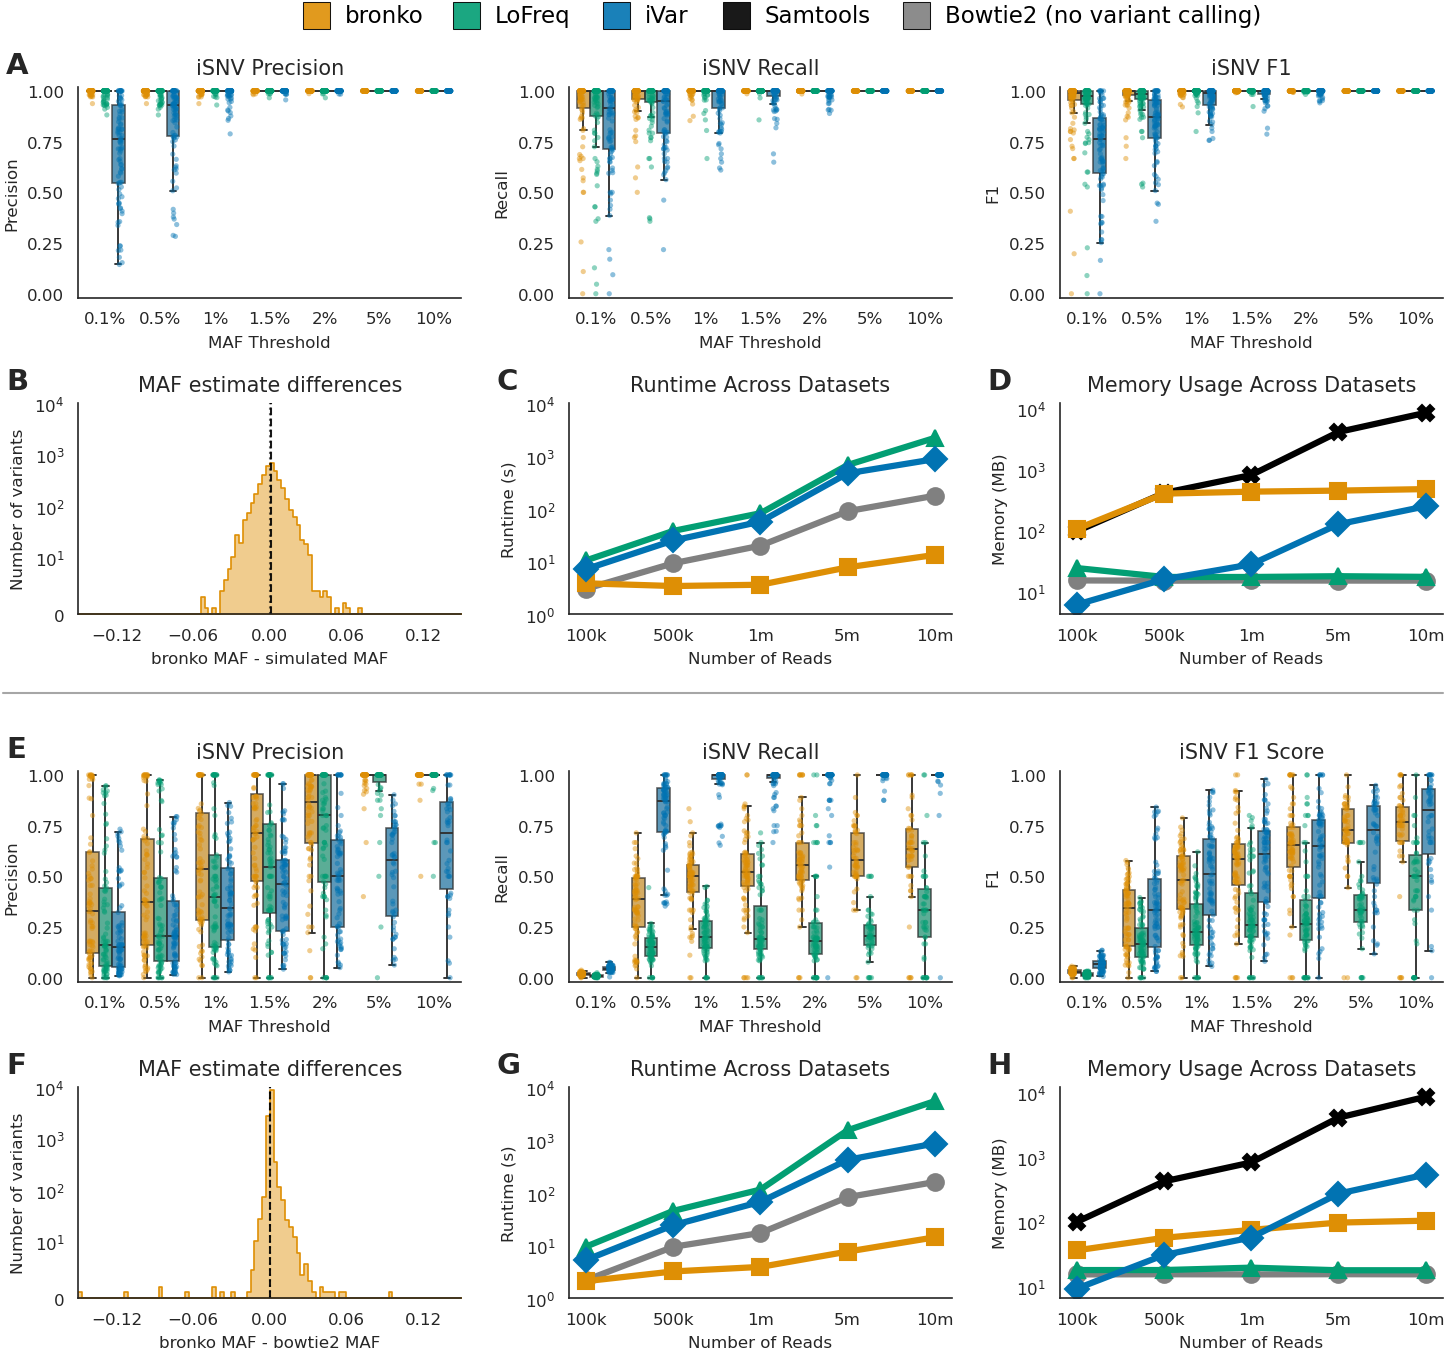

In [30]:
sns.set_theme(style="white")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 10,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "xtick.major.size": 3, "ytick.major.size": 3,
    "lines.linewidth": 1.5, "lines.markersize": 5,
    "savefig.dpi": 600, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "figure.dpi": 150, "figure.facecolor": "white", "axes.facecolor": "white",
})

# Which truth benchmark the top block draws. Both are loaded and analysed above; the one
# left out here is the supplementary figure.
TOP_BENCHMARK = 'RSV-A'
top_metrics, top_diff = {'RSV-A': (rsva_metrics, diff_rsva),
                         'Ebola': (ebola_metrics, diff_ebola)}[TOP_BENCHMARK]

FIG_W, FIG_H = 10, 9.5
fig = plt.figure(figsize=(FIG_W, FIG_H))

# the two blocks are given identical heights (.37 of the figure each) so every row in
# the figure is the same size; .09 between them holds the rule and the top block's x-labels
BLOCK_H, BLOCK_GAP, TOP = .37, .11, .90
gs_top = fig.add_gridspec(
    2, 3, left=.07, right=.98, top=TOP, bottom=TOP - BLOCK_H,
    hspace=.50, wspace=.28
)
gs_bot = fig.add_gridspec(
    2, 3, left=.07, right=.98, top=TOP - BLOCK_H - BLOCK_GAP,
    bottom=TOP - 2 * BLOCK_H - BLOCK_GAP,
    hspace=.50, wspace=.28
)

ax_top = np.array([[fig.add_subplot(gs_top[r, c]) for c in range(3)] for r in range(2)])
ax_bot = np.array([[fig.add_subplot(gs_bot[r, c]) for c in range(3)] for r in range(2)])

# A
plot_row(top_metrics, ax_top[0], show_titles=True, show_xlabel=True)

# B: same histogram as F, against the simulated AF rather than the bowtie2 pileup
# n_ticks: this error range is ~10x tighter than the HPV one below, so its labels carry
# three decimals and ten of them would overlap
plot_maf_diff(ax_top[1, 0], top_diff, xlabel="bronko MAF - simulated MAF", n_ticks=5,
              yscale='symlog', xlim=[-0.15, 0.15], ylim=[0, 10000])

# C / D: the RSV-A depth sweep. One folder per depth holding both the timings and the
# memory figures, so the same folder list drives both panels (the HPV runs below measured
# the two separately, hence the *_reads / *_reads_mem split there).
plot_times_across_folders(RSVA_RUNTIME_FOLDERS, ax_top[1, 1], xticklabels=READ_LABELS,
                          pre=RSVA_RUNTIME_ROOT, overview_rel='overview.tsv')
plot_memory_across_folders(RSVA_RUNTIME_FOLDERS, ax_top[1, 2], xticklabels=READ_LABELS,
                           pre=RSVA_RUNTIME_ROOT, overview_rel='overview.tsv')

# E
plot_precision_recall_f1(
    folder_metrics, ax_bot[0], kind='box', show_dots=True,
    dot_size=2.5, dot_alpha=.45
)

# F / G / H
bronko_vars = bronko_calls(mr1e_minors)
plot_bronko_maf_diff(ax_bot[1, 0], bronko_vars, xlim=[-0.15, 0.15], ylim=[0, 10000], n_ticks=5)
plot_times_across_folders(
    ['100k_reads', '500k_reads', '1m_reads', '5m_reads', '10m_reads'],
    ax_bot[1, 1]
)
plot_memory_across_folders(
    ['100k_reads_mem', '500k_reads_mem', '1m_reads_mem', '5m_reads_mem', '10m_reads_mem'],
    ax_bot[1, 2]
)

# Separator
RULE_Y = TOP - BLOCK_H - BLOCK_GAP / 2
fig.add_artist(Line2D(
    [.02, .98], [RULE_Y, RULE_Y], transform=fig.transFigure,
    color='0.65', linewidth=1
))

# Legend
labels = ["bronko", "LoFreq", "iVar", "Samtools", "Bowtie2 (no variant calling)"]
colors = [_base_palette[1], _base_palette[2], _base_palette[0], "black", "gray"]
swatch_legend(fig, labels, colors, y=.95,
              x_positions=[.22, .32, .42, .50, .62])

# Panel letters
for a, l in zip(
    [ax_top[0, 0], ax_top[1, 0], ax_top[1, 1], ax_top[1, 2],
     ax_bot[0, 0], ax_bot[1, 0], ax_bot[1, 1], ax_bot[1, 2]],
    "ABCDEFGH"
):
    panel_letter(fig, a, l, dy=0.025)

for ext in ('png', 'pdf', 'svg'):
    fig.savefig(FIGURES_DIR / f'Figure2_combined.{ext}',
                bbox_inches='tight', dpi=600, facecolor='white')

plt.show()

## Supplementary: the other benchmark

The four panels of the top block again, for whichever of RSV-A / Ebola the main figure
does not show -- Ebola while `TOP_BENCHMARK` is `'RSV-A'`, and the other way round if that
is switched. Same block geometry as the top half of Figure 2, so the two read as the same
figure at the same scale: .37 of an 8-inch figure is 2.96 in of panel, which is what
.86 -> .12 of a 4-inch figure gives.

saved Figure2_supp_Ebola (10 x 4.75 in)


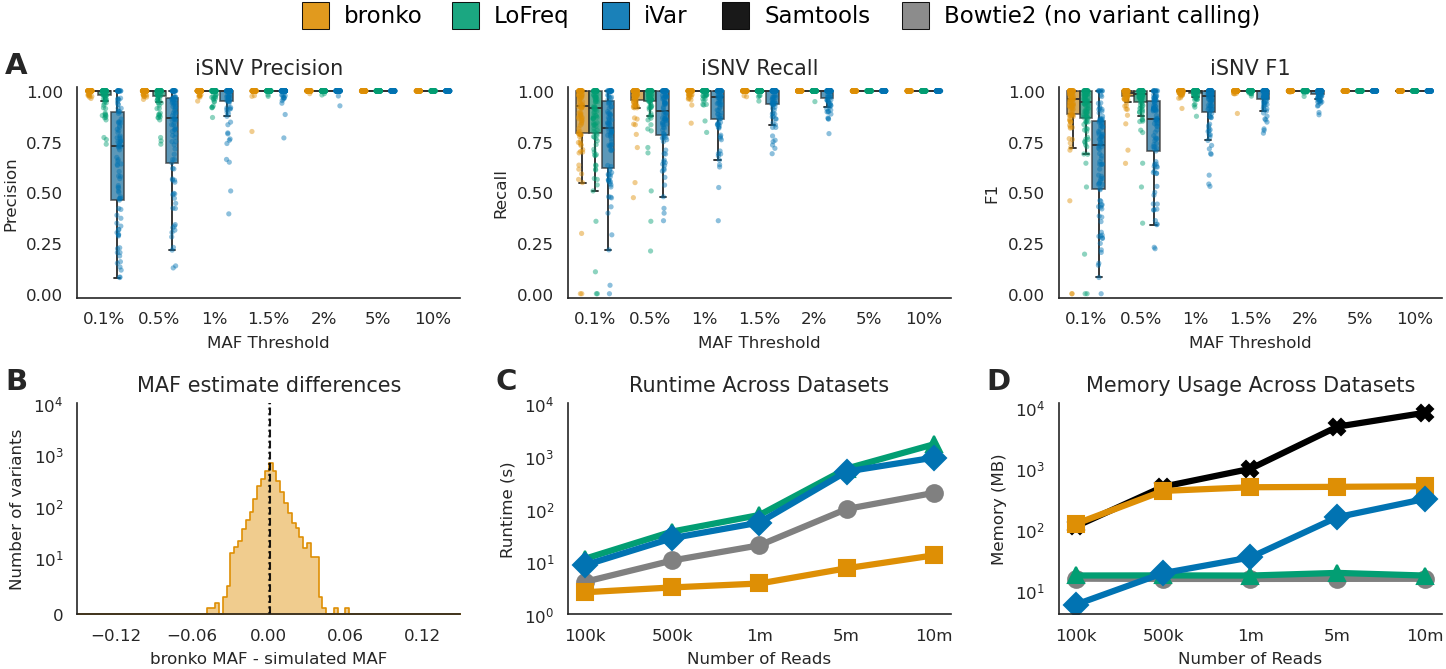

In [45]:
SUPP_BENCHMARK = 'Ebola' if TOP_BENCHMARK == 'RSV-A' else 'RSV-A'
supp_metrics, supp_diff = {'RSV-A': (rsva_metrics, diff_rsva),
                           'Ebola': (ebola_metrics, diff_ebola)}[SUPP_BENCHMARK]

# Geometry is derived from the main figure rather than repeated, so the panels here stay
# the same physical size as the block they mirror: the block up there is BLOCK_H of a
# FIG_H-inch figure, so the height that gives the same inches between SUPP_TOP and
# SUPP_BOTTOM is BLOCK_H * FIG_H / (SUPP_TOP - SUPP_BOTTOM). The legend and the panel
# letters are then offset by the same fraction of an inch as they are up there.
SUPP_TOP, SUPP_BOTTOM = .86, .12
SUPP_H = BLOCK_H * FIG_H / (SUPP_TOP - SUPP_BOTTOM)
SUPP_SCALE = FIG_H / SUPP_H

fig_s = plt.figure(figsize=(FIG_W, SUPP_H))
gs_s = fig_s.add_gridspec(
    2, 3, left=.07, right=.98, top=SUPP_TOP, bottom=SUPP_BOTTOM,
    hspace=.50, wspace=.28
)
ax_s = np.array([[fig_s.add_subplot(gs_s[r, c]) for c in range(3)] for r in range(2)])

# A
plot_row(supp_metrics, ax_s[0], show_titles=True, show_xlabel=True)

# B: same settings as the main figure's B, so the two histograms are directly comparable
plot_maf_diff(ax_s[1, 0], supp_diff, xlabel="bronko MAF - simulated MAF", n_ticks=5,
              yscale='symlog', xlim=[-0.15, 0.15], ylim=[0, 10000])

# C / D: the same slots -- this benchmark has no runtime numbers either yet
plot_times_across_folders(EBOLA_RUNTIME_FOLDERS, ax_s[1, 1], xticklabels=READ_LABELS,
                          pre=EBOLA_RUNTIME_ROOT, overview_rel='overview.tsv')
plot_memory_across_folders(EBOLA_RUNTIME_FOLDERS, ax_s[1, 2], xticklabels=READ_LABELS,
                           pre=EBOLA_RUNTIME_ROOT, overview_rel='overview.tsv')

# Legend: the five-tool key of the main figure, so the two match once C and D are filled
supp_labels = ["bronko", "LoFreq", "iVar", "Samtools", "Bowtie2 (no variant calling)"]
supp_colors = [_base_palette[1], _base_palette[2], _base_palette[0], "black", "gray"]
swatch_legend(fig_s, supp_labels, supp_colors,
              y=SUPP_TOP + (.95 - TOP) * SUPP_SCALE,
              x_positions=[.22, .32, .42, .50, .62])

# Panel letters
for a, l in zip([ax_s[0, 0], ax_s[1, 0], ax_s[1, 1], ax_s[1, 2]], "ABCD"):
    panel_letter(fig_s, a, l, dy=.025 * SUPP_SCALE)

supp_stem = f"Figure2_supp_{SUPP_BENCHMARK.replace('-', '')}"
for ext in ('png', 'pdf', 'svg'):
    fig_s.savefig(FIGURES_DIR / f'{supp_stem}.{ext}',
                  bbox_inches='tight', dpi=600, facecolor='white')
print('saved', supp_stem, f'({FIG_W} x {SUPP_H:g} in)')

plt.show()


## Supplementary: HPV16 from the other cache

The HPV block again (**A** -- **D**), built from `HPV_SUPP_CACHE_DIR` instead of
`HPV_CACHE_DIR`, so Figure 2 keeps one analysis of the runs and this shows the other.
Skipped entirely while `HPV_SUPP_CACHE_DIR` is `None`.

Same block geometry as the top half of Figure 2, so the panels are the same physical size
and the two are directly comparable.

**C** and **D** are identical to the main figure's **G** and **H**: runtime and memory come
from `simulated_hpv_runs/*/sample_1/overview.tsv`, which neither cache touches. They are
kept so the supplement stands on its own; drop the two calls for a two-panel figure if the
duplication reads as a difference that isn't there.

saved Figure2_supp_HPV from bronko_eval_cache_supp


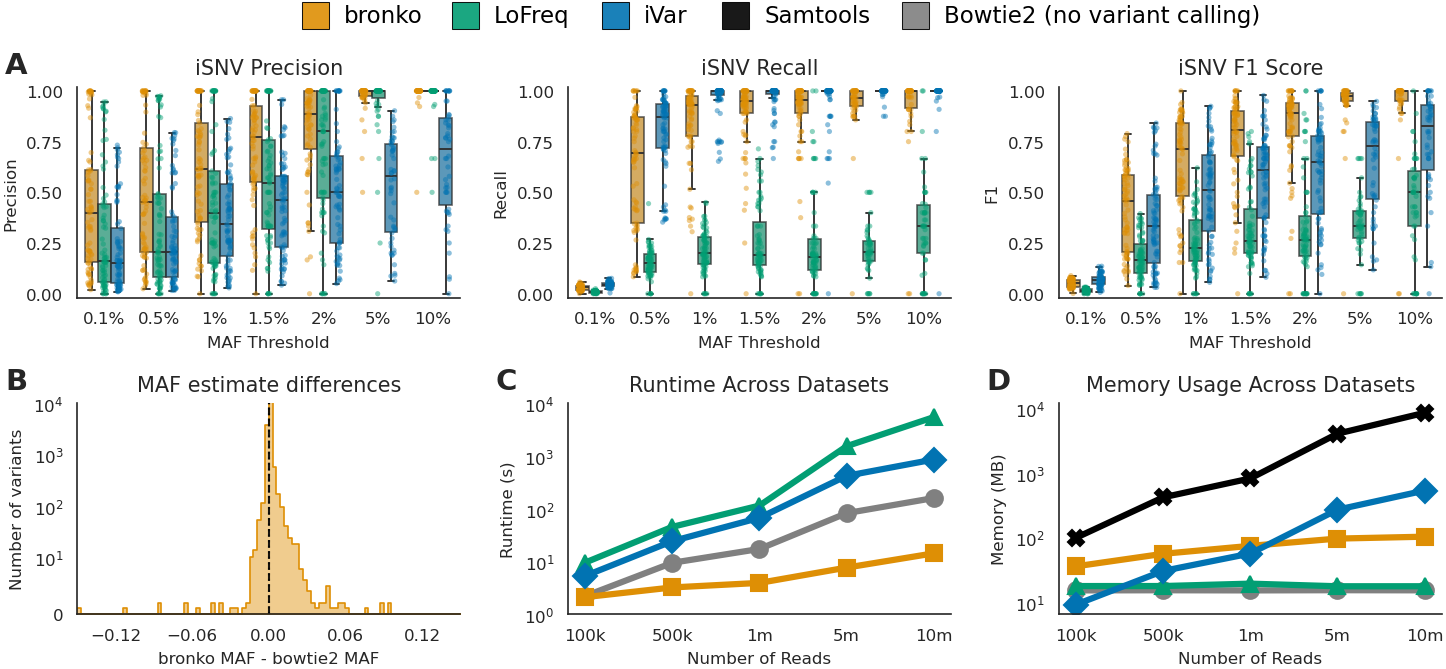

In [32]:
if supp_folder_metrics is None:
    print('HPV_SUPP_CACHE_DIR is None -- skipping the HPV supplementary figure')
else:
    # Same geometry derivation as the Ebola supplement: the block in the main figure is
    # BLOCK_H of a FIG_H-inch figure, so spanning the same inches between SUPP_TOP and
    # SUPP_BOTTOM keeps the panels the same physical size.
    fig_h = plt.figure(figsize=(FIG_W, SUPP_H))
    gs_h = fig_h.add_gridspec(
        2, 3, left=.07, right=.98, top=SUPP_TOP, bottom=SUPP_BOTTOM,
        hspace=.50, wspace=.28
    )
    ax_h = np.array([[fig_h.add_subplot(gs_h[r, c]) for c in range(3)] for r in range(2)])

    # A
    plot_precision_recall_f1(
        supp_folder_metrics, ax_h[0], kind='box', show_dots=True,
        dot_size=2.5, dot_alpha=.45
    )

    # B: the same settings as the main figure's F, so the two histograms are comparable
    plot_bronko_maf_diff(ax_h[1, 0], supp_bronko_vars,
                         xlim=[-0.15, 0.15], ylim=[0, 10000], n_ticks=5)

    # C / D: the resource benchmark, unchanged between the two settings (see the markdown)
    plot_times_across_folders(
        ['100k_reads', '500k_reads', '1m_reads', '5m_reads', '10m_reads'],
        ax_h[1, 1]
    )
    plot_memory_across_folders(
        ['100k_reads_mem', '500k_reads_mem', '1m_reads_mem', '5m_reads_mem', '10m_reads_mem'],
        ax_h[1, 2]
    )

    # Legend
    hpv_supp_labels = ["bronko", "LoFreq", "iVar", "Samtools", "Bowtie2 (no variant calling)"]
    hpv_supp_colors = [_base_palette[1], _base_palette[2], _base_palette[0], "black", "gray"]
    swatch_legend(fig_h, hpv_supp_labels, hpv_supp_colors,
                  y=SUPP_TOP + (.95 - TOP) * SUPP_SCALE,
                  x_positions=[.22, .32, .42, .50, .62])

    # Panel letters
    for a, l in zip([ax_h[0, 0], ax_h[1, 0], ax_h[1, 1], ax_h[1, 2]], "ABCD"):
        panel_letter(fig_h, a, l, dy=.025 * SUPP_SCALE)

    for ext in ('png', 'pdf', 'svg'):
        fig_h.savefig(FIGURES_DIR / f'Figure2_supp_HPV.{ext}',
                      bbox_inches='tight', dpi=600, facecolor='white')
    print(f'saved Figure2_supp_HPV from {Path(HPV_SUPP_CACHE_DIR).name}')

    plt.show()

In [ ]:
print(len(bronko_vars[bronko_vars['maf difference'].abs() < 0.03]))
print(len(bronko_vars))
print(len(bronko_vars[bronko_vars['maf difference'].abs() < 0.03]) / len(bronko_vars))

12236
12279
0.9964980861633683


In [43]:
print(len(top_diff[top_diff.abs() < 0.03]))
print(len(top_diff))
print(len(top_diff[top_diff.abs() < 0.03]) / len(top_diff))

3791
3848
0.9851871101871101
